[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pmarcelino/mobillity-courses/blob/main/mobillity-univ/module-6-telling-the-story/notebook-6.4-quick-and-academic-presentations-marp-and-beamer.ipynb)


# Quick and academic presentations: one FGC analysis, two more formats

The previous lesson turned the verified evening-service analysis into a PowerPoint file and a web deck. This one adds two lighter-weight formats for different rooms: **Marp** for a quick internal deck written in markdown, and **Beamer** for an academic, conference-style talk. Both start from the same analysis and the same executive brief - only the output format changes.

In [1]:
# --- Setup: install the presentation tools this notebook uses --------------
# On Google Colab the first run installs these (LaTeX takes a few minutes);
# locally each step is skipped when the tool is already present. Safe to re-run.
import importlib.util, os, shutil, subprocess, sys

# PyMuPDF (imported as "fitz") - previews the compiled Beamer PDF
if importlib.util.find_spec("fitz") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymupdf"], check=True)

# Marp CLI - renders the Marp markdown deck to slide images (Node + Chromium)
if shutil.which("marp") is None:
    subprocess.run("npm install -g @marp-team/marp-cli", shell=True, check=True)
    subprocess.run("apt-get -qq update && apt-get -qq install -y chromium-browser", shell=True, check=False)
for _chrome in ("/usr/bin/chromium-browser", "/usr/bin/chromium", "/usr/bin/google-chrome"):
    if os.path.exists(_chrome):
        os.environ.setdefault("CHROME_PATH", _chrome)
        break

# LaTeX + Beamer - compiles the academic deck to a PDF
if shutil.which("pdflatex") is None:
    subprocess.run(
        "apt-get -qq update && apt-get -qq install -y "
        "texlive-latex-base texlive-latex-recommended texlive-fonts-recommended "
        "texlive-pictures texlive-latex-extra",
        shell=True, check=True)
print("SETUP_OK: marp, pdflatex, fitz available")

SETUP_OK: marp, pdflatex, fitz available


## 1. The verified analysis, carried in from the previous lesson

The per-line evening-service table is already in the notebook - one row per FGC line for a representative weekday evening (20:00-24:00). We do not re-run the analysis; we start from that verified result and turn it into slides.

In [2]:
"""
The verified per-line evening-service table - carried forward from the previous lesson,
not recomputed here.

This is the analysis already in the notebook: one row per FGC line for a representative
weekday evening (20:00-24:00), validated against the real feed earlier in the course. This
lesson starts from that result and turns it into slides - it does not re-run the analysis.

Columns: line code, mode, evening departures, departures/hour, worst-direction wait (min).
"""
import pandas as pd

# One row per FGC line (sorted shortest evening wait first). Already in the notebook.
line_table = pd.DataFrame(
    [
        ("FV", "funicular", 80, 20.0, 6),
        ("L7", "metro", 56, 14.0, 9),
        ("L12", "metro", 45, 11.2, 11),
        ("L6", "metro", 39, 9.8, 13),
        ("S1", "rail", 25, 6.2, 24),
        ("S2", "rail", 25, 6.2, 24),
        ("L8", "metro", 16, 4.0, 34),
        ("R63", "rail", 3, 0.8, 80),
        ("S8", "rail", 14, 3.5, 80),
        ("R53", "rail", 2, 0.5, 120),
        ("S3", "rail", 5, 1.2, 120),
        ("S4", "rail", 4, 1.0, 120),
        ("R5", "rail", 7, 1.8, 240),
        ("R6", "rail", 6, 1.5, 240),
        ("RL1", "rail", 3, 0.8, 240),
    ],
    columns=["route_short_name", "mode", "evening_departures", "dep_per_hour", "evening_wait_min"],
)

line_table

,route_short_name,mode,evening_departures,dep_per_hour,evening_wait_min
0,FV,funicular,80,20.0,6
1,L7,metro,56,14.0,9
2,L12,metro,45,11.2,11
3,L6,metro,39,9.8,13
4,S1,rail,25,6.2,24
5,S2,rail,25,6.2,24
6,L8,metro,16,4.0,34
7,R63,rail,3,0.8,80
8,S8,rail,14,3.5,80
9,R53,rail,2,0.5,120


Fifteen lines, 330 evening departures. The spread is stark: the funicular runs every 6 minutes while six rail lines wait 120-240 minutes between evening trains. Those are the numbers both decks will carry.

## 2. A quick internal deck with Marp

Marp turns markdown into slides, so instead of asking for slide-building code we ask the model directly for a Marp deck and render it.

Prompt to the assistant:

```markdown
Create a Marp presentation from this evening-service analysis and the executive brief. Write it as Marp markdown and follow the brief's pyramid: a title slide, the main finding on its own slide, one slide per reason with its supporting chart, and a closing recommendation. Keep it clean and readable for a lab meeting, then render the deck to slide images.
```

DECK_SAVED: fgc-evening-service.md | SLIDES_RENDERED: 6


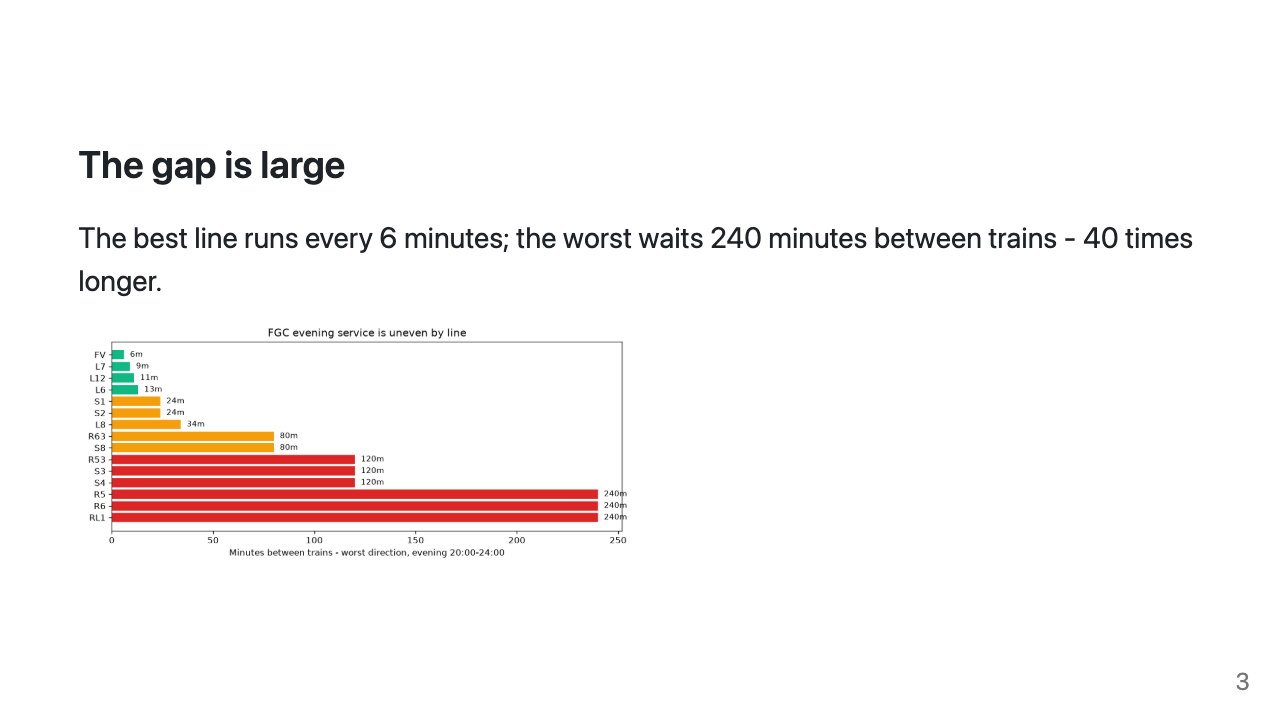

In [3]:
"""
Build a quick Marp deck from the same executive brief and evidence table.
Marp turns markdown into slides, so we write the deck as markdown, then render it.
"""
import subprocess, glob
import matplotlib
import matplotlib.pyplot as plt

DECK = "fgc-evening-service.md"
CHART = "fgc-evening-frequency.png"
GAP = "The gap is large"

# 1. The executive brief as a pyramid - one slide each (the narrative is already written)
brief = [
    ("FGC Evening Service", "Weekday evening, 20:00-24:00 - prepared for the transport authority."),
    ("Evening service is uneven", "Riders on the thinner-served lines wait far longer for a train than riders on the core network."),
    ("The gap is large", "The best line runs every 6 minutes; the worst waits 240 minutes between trains - 40 times longer."),
    ("Six lines are barely served", "R53, S3, S4, R5, R6 and RL1 wait two hours or more between evening trains."),
    ("The imbalance is structural", "The best line runs 20 trains an hour; the worst runs one every two hours."),
    ("Recommendation", "Add evening trips on the lines waiting two hours or more, then re-check after the next timetable change."),
]

# 2. Render the evidence chart the "gap" slide will carry
ranked = line_table.sort_values("evening_wait_min")
colors = ["#10B981" if w <= 15 else "#F59E0B" if w < 120 else "#DC2626" for w in ranked.evening_wait_min]
cfig, ax = plt.subplots(figsize=(9, 4))
ax.barh(ranked.route_short_name, ranked.evening_wait_min, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Minutes between trains - worst direction, evening 20:00-24:00")
ax.set_title("FGC evening service is uneven by line")
for i, w in enumerate(ranked.evening_wait_min):
    ax.text(w + 3, i, f"{int(w)}m", va="center", fontsize=9)
cfig.tight_layout(); cfig.savefig(CHART, dpi=120); plt.close(cfig)

# 3. Lay the deck out in Marp markdown: front-matter, then one slide per "---"
slides = [f"# {brief[0][0]}\n\n{brief[0][1]}"]
for heading, line in brief[1:]:
    chart_md = f"\n\n![w:560]({CHART})" if heading == GAP else ""
    slides.append(f"## {heading}\n\n{line}{chart_md}")
markdown = "---\nmarp: true\npaginate: true\n---\n\n" + "\n\n---\n\n".join(slides) + "\n"
open(DECK, "w").write(markdown)

# 4. Render the markdown to slide images with the Marp CLI, then show the evidence slide
subprocess.run(["marp", DECK, "--images", "png", "--allow-local-files"], check=True, capture_output=True)
pages = sorted(glob.glob("fgc-evening-service.*.png"))
print("DECK_SAVED:", DECK, "| SLIDES_RENDERED:", len(pages))

from IPython.display import Image
Image(filename=pages[[h for h, _ in brief].index(GAP)])

Rendered with the Marp CLI, the markdown becomes a clean six-slide deck. The evidence slide shown above carries the same chart, straight from the table - exactly the quick, readable format you want for a lab meeting.

## 3. An academic deck with Beamer

Beamer produces LaTeX slides that compile to a conference-style PDF, with real typeset math and formal formatting. You never write the LaTeX by hand - the model does, and the renderer compiles it.

Prompt to the assistant:

```markdown
Now build the same presentation as an academic Beamer deck. Write the LaTeX and keep the same pyramid - a title frame, the main finding, one frame per reason with the evidence chart, and the recommendation. Show the 40x gap as a typeset equation, use a conference-style theme, and compile it to a PDF.
```

DECK_SAVED: fgc-evening-service.pdf | SLIDES_COMPILED: 6


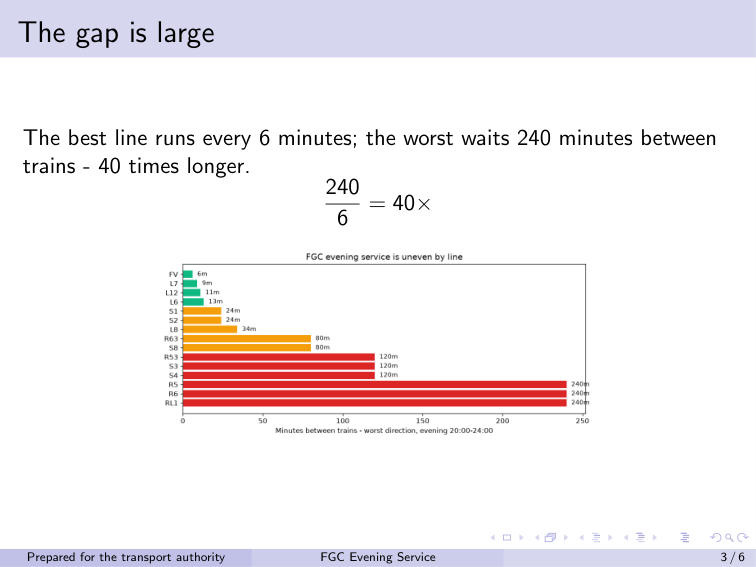

In [4]:
"""
Build an academic Beamer deck from the same brief, as LaTeX, then compile it to PDF.
Beamer produces conference-standard slides with real typeset math - you write the LaTeX
(here, the model does) and the renderer compiles it.
"""
import subprocess
import matplotlib
import matplotlib.pyplot as plt
import fitz  # PyMuPDF - to show the compiled PDF

DECK = "fgc-evening-service.tex"
CHART = "fgc-evening-frequency.png"
GAP = "The gap is large"

# 1. The same executive brief as a pyramid - one frame each
brief = [
    ("FGC Evening Service", "Weekday evening, 20:00-24:00 - prepared for the transport authority."),
    ("Evening service is uneven", "Riders on the thinner-served lines wait far longer for a train than riders on the core network."),
    ("The gap is large", "The best line runs every 6 minutes; the worst waits 240 minutes between trains - 40 times longer."),
    ("Six lines are barely served", "R53, S3, S4, R5, R6 and RL1 wait two hours or more between evening trains."),
    ("The imbalance is structural", "The best line runs 20 trains an hour; the worst runs one every two hours."),
    ("Recommendation", "Add evening trips on the lines waiting two hours or more, then re-check after the next timetable change."),
]

# 2. Render the evidence chart the "gap" frame will carry
ranked = line_table.sort_values("evening_wait_min")
colors = ["#10B981" if w <= 15 else "#F59E0B" if w < 120 else "#DC2626" for w in ranked.evening_wait_min]
cfig, ax = plt.subplots(figsize=(9, 4))
ax.barh(ranked.route_short_name, ranked.evening_wait_min, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Minutes between trains - worst direction, evening 20:00-24:00")
ax.set_title("FGC evening service is uneven by line")
for i, w in enumerate(ranked.evening_wait_min):
    ax.text(w + 3, i, f"{int(w)}m", va="center", fontsize=9)
cfig.tight_layout(); cfig.savefig(CHART, dpi=120); plt.close(cfig)

# 3. The LLM writes LaTeX: a title frame, one frame per point, the gap as a typeset equation
worst = int(line_table.evening_wait_min.max())
best = int(line_table.evening_wait_min.min())
ratio = worst // best

def frame(title, body, extra=""):
    return "\\begin{frame}{" + title + "}\n" + body + "\n" + extra + "\n\\end{frame}"

preamble = "\n".join([
    r"\documentclass{beamer}",
    r"\usetheme{Madrid}",
    r"\usecolortheme{seahorse}",
    r"\title{FGC Evening Service}",
    r"\subtitle{Weekday evening, 20:00--24:00}",
    r"\author{Prepared for the transport authority}",
    r"\date{}",
    r"\begin{document}",
    r"\frame{\titlepage}",
])
frames = []
for heading, line in brief[1:]:
    extra = ""
    if heading == GAP:
        extra = (r"\[ \frac{" + str(worst) + r"}{" + str(best) + r"} = " + str(ratio) + r"\times \]" + "\n"
                 r"\begin{center}\includegraphics[width=0.62\textwidth]{" + CHART + r"}\end{center}")
    frames.append(frame(heading, line, extra))
latex = preamble + "\n" + "\n".join(frames) + "\n\\end{document}\n"
open(DECK, "w").write(latex)

# 4. Compile the LaTeX to a real conference-style PDF, then show the evidence frame
subprocess.run(["pdflatex", "-interaction=nonstopmode", "-halt-on-error", DECK], check=True, capture_output=True)
doc = fitz.open("fgc-evening-service.pdf")
print("DECK_SAVED: fgc-evening-service.pdf | SLIDES_COMPILED:", doc.page_count)

doc[[h for h, _ in brief].index(GAP)].get_pixmap(dpi=150).save("beamer-slide.png")
from IPython.display import Image
Image(filename="beamer-slide.png")

Compiled with pdflatex, the LaTeX becomes an academic PDF: the Madrid theme, the 40x gap as a typeset equation, and the same evidence chart - the look expected in seminars, thesis defenses, and conference talks.

## Choosing between them

Same analysis, same pyramid narrative - the format follows the room. Reach for **Marp** when the audience is a team and you want speed and readability; reach for **Beamer** when the audience is academic and you need math, citations, and formal polish. Both are generated by directing the model, so your effort goes into the story, not the slide mechanics.